In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('data/financial_fraud_detection_dataset.csv')
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
0,T100000,CUST3252,04-10-2023 07:45,37.54,Travel,PayPal,POS,Bengaluru,0,94,417.40,1492,No,0
1,T100001,CUST1630,26-09-2023 08:29,240.81,Utilities,PayPal,Mobile,Bengaluru,0,76,335.47,66,No,0
2,T100002,CUST7852,18-07-2023 15:54,105.34,Entertainment,Debit Card,Mobile,Bengaluru,0,60,432.03,216,No,0
3,T100003,CUST4892,16-10-2023 17:10,73.04,Utilities,NetBanking,Desktop,Kolkata,0,68,488.30,449,No,0
4,T100004,CUST8831,09-09-2023 00:46,13.57,Utilities,Credit Card,Desktop,Bengaluru,0,57,437.03,754,No,0


In [4]:
df.shape

(5000, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         5000 non-null   str    
 1   Customer_ID            5000 non-null   str    
 2   Transaction_Date       5000 non-null   str    
 3   Transaction_Amount     5000 non-null   float64
 4   Merchant_Category      5000 non-null   str    
 5   Payment_Method         5000 non-null   str    
 6   Device_Type            5000 non-null   str    
 7   Location               5000 non-null   str    
 8   Is_International       5000 non-null   int64  
 9   Previous_Transactions  5000 non-null   int64  
 10  Average_Spend          5000 non-null   float64
 11  Account_Age_Days       5000 non-null   int64  
 12  Suspicious_Keyword     5000 non-null   str    
 13  Fraudulent             5000 non-null   int64  
dtypes: float64(2), int64(4), str(8)
memory usage: 844.6 KB


In [6]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Transaction_Date',
       'Transaction_Amount', 'Merchant_Category', 'Payment_Method',
       'Device_Type', 'Location', 'Is_International', 'Previous_Transactions',
       'Average_Spend', 'Account_Age_Days', 'Suspicious_Keyword',
       'Fraudulent'],
      dtype='str')

In [7]:
df.isnull().sum()

Transaction_ID           0
Customer_ID              0
Transaction_Date         0
Transaction_Amount       0
Merchant_Category        0
Payment_Method           0
Device_Type              0
Location                 0
Is_International         0
Previous_Transactions    0
Average_Spend            0
Account_Age_Days         0
Suspicious_Keyword       0
Fraudulent               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], format='%d-%m-%Y %H:%M')

In [10]:
df['Transaction_Date'].isnull().sum()

np.int64(0)

In [11]:
df['Fraudulent'].value_counts()

Fraudulent
0    4518
1     482
Name: count, dtype: int64

In [13]:
df.describe()

,Transaction_Date,Transaction_Amount,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Fraudulent
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2023-07-30 02:54:51.744000,79.180664,0.088200,99.414000,258.377132,1011.158200,0.096400
min,2023-01-01 02:16:00,0.000000,0.000000,1.000000,10.010000,30.000000,0.000000
25%,2023-04-18 23:04:15,22.365000,0.000000,50.000000,138.772500,530.000000,0.000000
50%,2023-07-31 02:27:00,55.455000,0.000000,100.000000,261.810000,1012.500000,0.000000
75%,2023-11-08 12:25:15,110.297500,0.000000,148.000000,378.525000,1496.000000,0.000000
max,2024-02-21 15:34:00,653.800000,1.000000,199.000000,499.990000,1999.000000,1.000000
std,NaN,78.964045,0.283614,57.022968,140.230639,568.633834,0.295169


Fraud vs Non-Fraud count (visual)

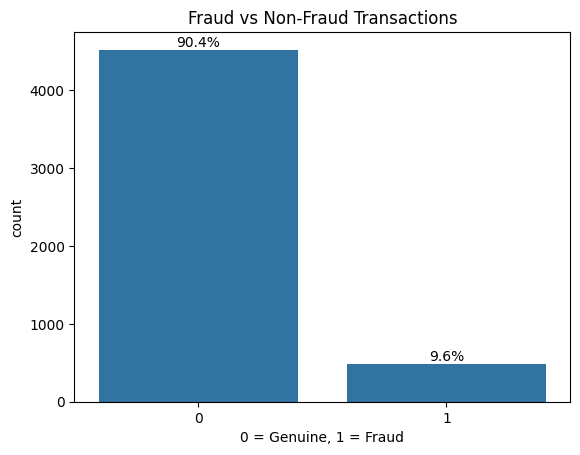

In [29]:
ax = sns.countplot(x='Fraudulent', data=df)
plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('0 = Genuine, 1 = Fraud')

total = len(df)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

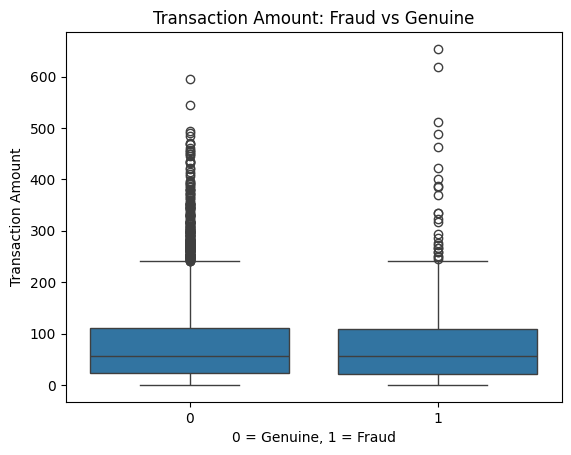

In [31]:
sns.boxplot(x='Fraudulent', y='Transaction_Amount', data=df)
plt.title('Transaction Amount: Fraud vs Genuine')
plt.xlabel('0 = Genuine, 1 = Fraud')
plt.ylabel('Transaction Amount')
plt.show()

In [19]:
pd.crosstab(df['Merchant_Category'], df['Fraudulent'], normalize='index')

Fraudulent,0,1
Merchant_Category,,
Electronics,0.924615,0.075385
Entertainment,0.885714,0.114286
Fashion,0.898026,0.101974
Food,0.891813,0.108187
Grocery,0.907790,0.092210
Health,0.899340,0.100660
Travel,0.906511,0.093489
Utilities,0.915825,0.084175


In [20]:
pd.crosstab(df['Device_Type'], df['Fraudulent'], normalize='index')

Fraudulent,0,1
Device_Type,,
Desktop,0.897558,0.102442
Mobile,0.908374,0.091626
POS,0.904961,0.095039


In [21]:
pd.crosstab(df['Suspicious_Keyword'], df['Fraudulent'], normalize='index')

Fraudulent,0,1
Suspicious_Keyword,,
No,0.924262,0.075738
Yes,0.526923,0.473077


In [22]:
pd.crosstab(df['Location'], df['Fraudulent'], normalize='index').sort_values(1, ascending=False)

Fraudulent,0,1
Location,,
Chennai,0.894656,0.105344
Mumbai,0.894737,0.105263
Bengaluru,0.896501,0.103499
Kolkata,0.897616,0.102384
Hyderabad,0.911724,0.088276
Pune,0.914127,0.085873
Delhi,0.914248,0.085752


In [23]:
pd.crosstab(df['Is_International'], df['Fraudulent'], normalize='index')

Fraudulent,0,1
Is_International,,
0,0.930029,0.069971
1,0.630385,0.369615


In [24]:
df['Hour'] = df['Transaction_Date'].dt.hour
df['Day_of_Week'] = df['Transaction_Date'].dt.day_name()

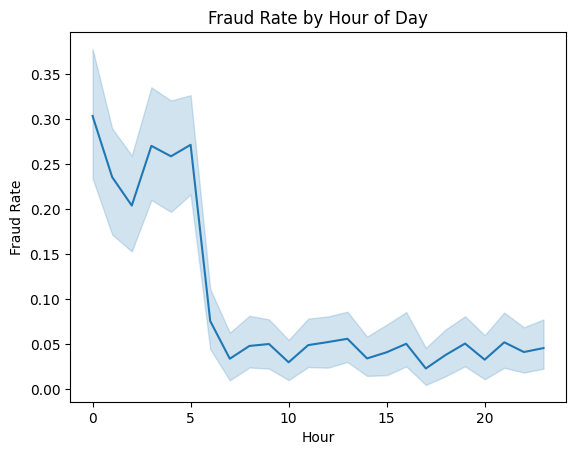

In [25]:
sns.lineplot(x='Hour', y='Fraudulent', data=df, estimator='mean')
plt.title('Fraud Rate by Hour of Day')
plt.ylabel('Fraud Rate')
plt.show()

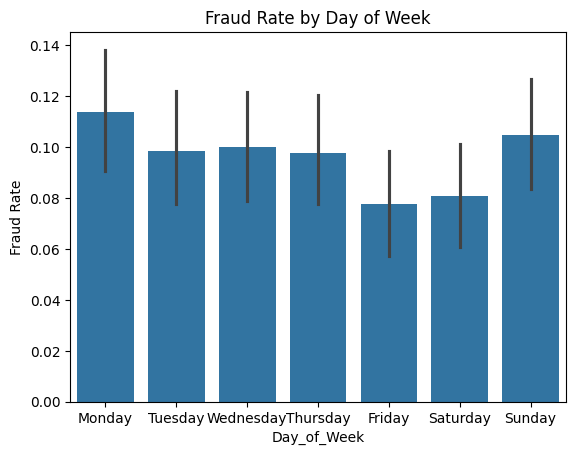

In [26]:
sns.barplot(x='Day_of_Week', y='Fraudulent', data=df, estimator='mean',
            order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Fraud Rate by Day of Week')
plt.ylabel('Fraud Rate')
plt.show()

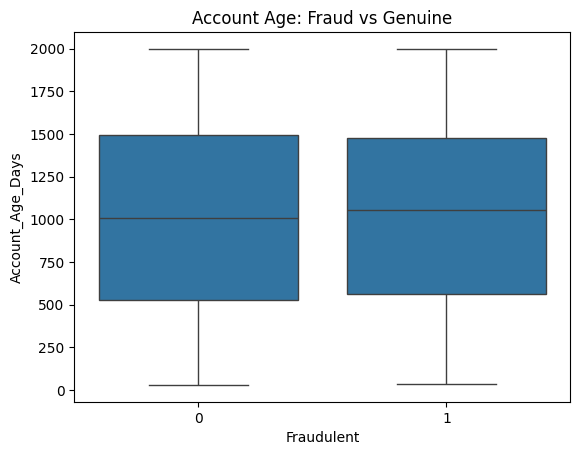

In [27]:
sns.boxplot(x='Fraudulent', y='Account_Age_Days', data=df)
plt.title('Account Age: Fraud vs Genuine')
plt.show()

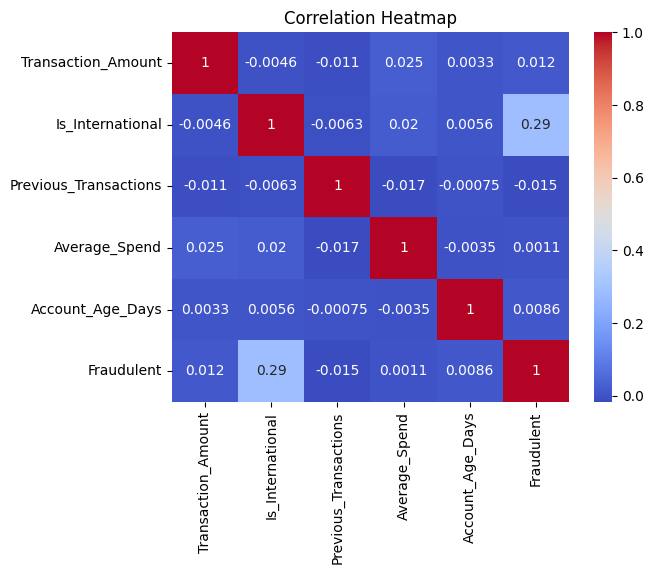

In [28]:
numeric_df = df[['Transaction_Amount', 'Is_International', 'Previous_Transactions',
                  'Average_Spend', 'Account_Age_Days', 'Fraudulent']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [32]:
df['Suspicious_Keyword_Flag'] = df['Suspicious_Keyword'].map({'Yes': 1, 'No': 0})

In [33]:
df['Is_Night'] = df['Hour'].apply(lambda x: 1 if x < 6 else 0)

In [34]:
df_encoded = pd.get_dummies(df, columns=['Merchant_Category', 'Device_Type', 'Payment_Method'], drop_first=True)

In [35]:
df_encoded.columns.tolist()

['Transaction_ID',
 'Customer_ID',
 'Transaction_Date',
 'Transaction_Amount',
 'Location',
 'Is_International',
 'Previous_Transactions',
 'Average_Spend',
 'Account_Age_Days',
 'Suspicious_Keyword',
 'Fraudulent',
 'Hour',
 'Day_of_Week',
 'Suspicious_Keyword_Flag',
 'Is_Night',
 'Merchant_Category_Entertainment',
 'Merchant_Category_Fashion',
 'Merchant_Category_Food',
 'Merchant_Category_Grocery',
 'Merchant_Category_Health',
 'Merchant_Category_Travel',
 'Merchant_Category_Utilities',
 'Device_Type_Mobile',
 'Device_Type_POS',
 'Payment_Method_Debit Card',
 'Payment_Method_NetBanking',
 'Payment_Method_PayPal',
 'Payment_Method_UPI']

In [36]:
feature_cols = ['Transaction_Amount', 'Is_International', 'Previous_Transactions',
                 'Average_Spend', 'Account_Age_Days', 'Suspicious_Keyword_Flag', 'Is_Night',
                 'Merchant_Category_Entertainment', 'Merchant_Category_Fashion',
                 'Merchant_Category_Food', 'Merchant_Category_Grocery',
                 'Merchant_Category_Health', 'Merchant_Category_Travel',
                 'Merchant_Category_Utilities', 'Device_Type_Mobile', 'Device_Type_POS',
                 'Payment_Method_Debit Card', 'Payment_Method_NetBanking',
                 'Payment_Method_PayPal', 'Payment_Method_UPI']

X = df_encoded[feature_cols]
y = df_encoded['Fraudulent']

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [41]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(4000, 20) (1000, 20)
Fraudulent
0    3614
1     386
Name: count, dtype: int64
Fraudulent
0    904
1     96
Name: count, dtype: int64


In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [43]:
y_pred = model.predict(X_test)

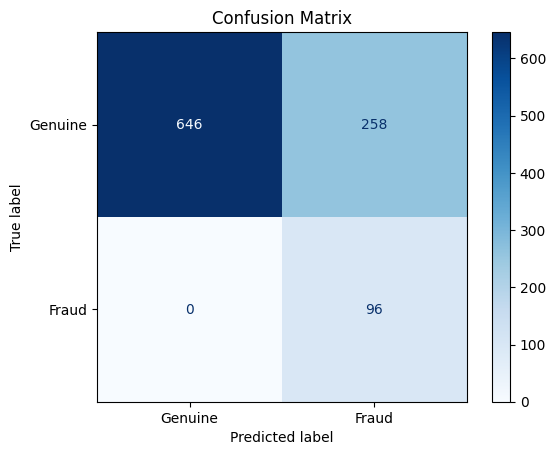

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Genuine', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Genuine', 'Fraud']))

              precision    recall  f1-score   support

     Genuine       1.00      0.71      0.83       904
       Fraud       0.27      1.00      0.43        96

    accuracy                           0.74      1000
   macro avg       0.64      0.86      0.63      1000
weighted avg       0.93      0.74      0.79      1000



In [46]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC Score: {auc_score:.3f}')

ROC-AUC Score: 0.885


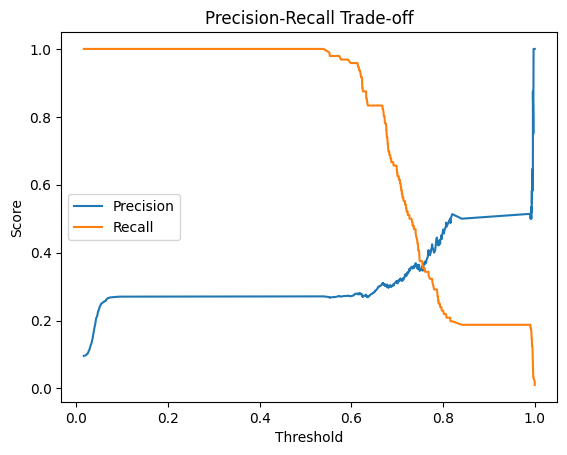

In [47]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off')
plt.legend()
plt.show()

In [48]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(importance)

                            Feature  Coefficient
5           Suspicious_Keyword_Flag     4.521806
1                  Is_International     4.279729
6                          Is_Night     4.142548
8         Merchant_Category_Fashion     0.367280
7   Merchant_Category_Entertainment     0.272954
9            Merchant_Category_Food     0.121978
11         Merchant_Category_Health     0.076102
19               Payment_Method_UPI     0.047672
10        Merchant_Category_Grocery     0.017279
0                Transaction_Amount     0.001768
3                     Average_Spend     0.000564
4                  Account_Age_Days     0.000015
2             Previous_Transactions    -0.001311
15                  Device_Type_POS    -0.027549
16        Payment_Method_Debit Card    -0.034411
18            Payment_Method_PayPal    -0.061906
17        Payment_Method_NetBanking    -0.116806
13      Merchant_Category_Utilities    -0.178736
14               Device_Type_Mobile    -0.201292
12         Merchant_

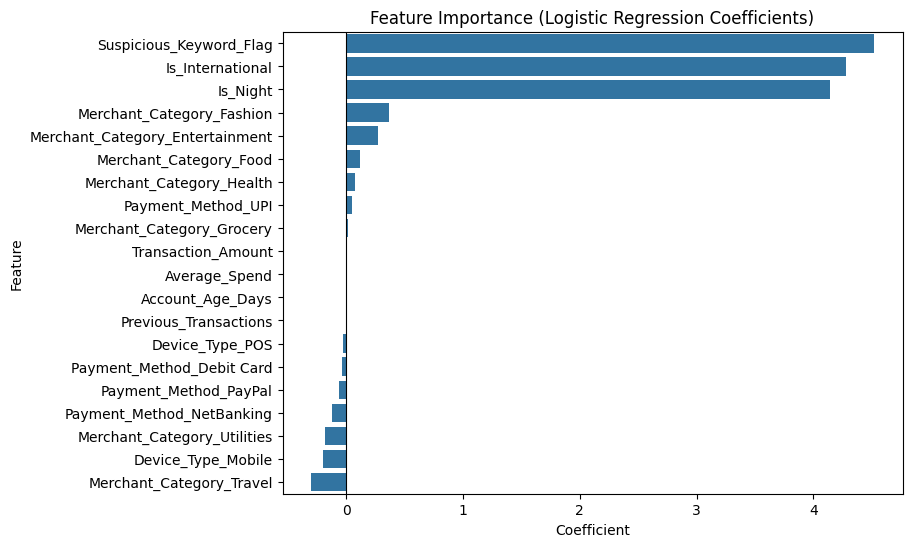

In [49]:
plt.figure(figsize=(8,6))
sns.barplot(x='Coefficient', y='Feature', data=importance)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

In [63]:
conn = sqlite3.connect('database/fraud_detection.db')

In [64]:
df_encoded.to_sql('transactions', conn, if_exists='replace', index=False)

5000

In [65]:
check = pd.read_sql('SELECT * FROM transactions LIMIT 5', conn)
check

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,...,Merchant_Category_Grocery,Merchant_Category_Health,Merchant_Category_Travel,Merchant_Category_Utilities,Device_Type_Mobile,Device_Type_POS,Payment_Method_Debit Card,Payment_Method_NetBanking,Payment_Method_PayPal,Payment_Method_UPI
0,T100000,CUST3252,2023-10-04 07:45:00,37.54,Bengaluru,0,94,417.40,1492,No,...,0,0,1,0,0,1,0,0,1,0
1,T100001,CUST1630,2023-09-26 08:29:00,240.81,Bengaluru,0,76,335.47,66,No,...,0,0,0,1,1,0,0,0,1,0
2,T100002,CUST7852,2023-07-18 15:54:00,105.34,Bengaluru,0,60,432.03,216,No,...,0,0,0,0,1,0,1,0,0,0
3,T100003,CUST4892,2023-10-16 17:10:00,73.04,Kolkata,0,68,488.30,449,No,...,0,0,0,1,0,0,0,1,0,0
4,T100004,CUST8831,2023-09-09 00:46:00,13.57,Bengaluru,0,57,437.03,754,No,...,0,0,0,1,0,0,0,0,0,0


In [66]:
count = pd.read_sql('SELECT COUNT(*) as total FROM transactions', conn)
count

,total
0,5000


In [67]:
conn.close()

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [69]:
print(classification_report(y_test, y_pred_rf, target_names=['Genuine', 'Fraud']))

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print(f'Random Forest AUC: {roc_auc_score(y_test, y_prob_rf):.3f}')

              precision    recall  f1-score   support

     Genuine       0.93      0.93      0.93       904
       Fraud       0.34      0.32      0.33        96

    accuracy                           0.88      1000
   macro avg       0.64      0.63      0.63      1000
weighted avg       0.87      0.88      0.87      1000

Random Forest AUC: 0.884


In [70]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(contamination=0.0964, random_state=42)
iso_model.fit(X_train)

# -1 = anomaly (potential fraud), 1 = normal
iso_pred = iso_model.predict(X_test)
iso_pred_binary = [1 if x == -1 else 0 for x in iso_pred]

In [71]:
print(classification_report(y_test, iso_pred_binary, target_names=['Genuine', 'Fraud']))

              precision    recall  f1-score   support

     Genuine       0.93      0.93      0.93       904
       Fraud       0.36      0.36      0.36        96

    accuracy                           0.88      1000
   macro avg       0.65      0.65      0.65      1000
weighted avg       0.88      0.88      0.88      1000



In [72]:
import pickle

with open('models/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved successfully.")

Model saved successfully.


In [73]:
with open('models/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

In [74]:
import datetime

def check_and_alert(transaction_id, fraud_probability, threshold=0.5):
    if fraud_probability >= threshold:
        timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        alert_msg = f"[{timestamp}] ALERT! Transaction {transaction_id} flagged as FRAUD (probability: {fraud_probability:.2%})"
        print(alert_msg)
        return alert_msg
    return None

In [75]:
def log_alert(alert_msg, log_file='outputs/fraud_alerts.log'):
    if alert_msg:
        with open(log_file, 'a') as f:
            f.write(alert_msg + '\n')

In [76]:
test_msg = check_and_alert('T999999', 0.85)
log_alert(test_msg)

[2026-08-25 14:38:19] ALERT! Transaction T999999 flagged as FRAUD (probability: 85.00%)


In [77]:
import os
print(os.path.exists('outputs/fraud_alerts.log'))

with open('outputs/fraud_alerts.log', 'r') as f:
    print(f.read())

True
[2026-08-25 14:38:19] ALERT! Transaction T999999 flagged as FRAUD (probability: 85.00%)



In [78]:
with open('outputs/fraud_alerts.log', 'r') as f:
    print(f.read())

[2026-08-25 14:38:19] ALERT! Transaction T999999 flagged as FRAUD (probability: 85.00%)
[2026-08-25 14:45:11] ALERT! Transaction T100004 flagged as FRAUD (probability: 66.86%)
[2026-08-25 14:45:12] ALERT! Transaction T100005 flagged as FRAUD (probability: 56.20%)
[2026-08-25 14:45:19] ALERT! Transaction T100012 flagged as FRAUD (probability: 66.01%)
[2026-08-25 14:45:23] ALERT! Transaction T100016 flagged as FRAUD (probability: 57.97%)
[2026-08-25 14:45:26] ALERT! Transaction T100019 flagged as FRAUD (probability: 62.24%)
[2026-08-25 14:45:31] ALERT! Transaction T100024 flagged as FRAUD (probability: 66.89%)
[2026-08-25 14:45:32] ALERT! Transaction T100025 flagged as FRAUD (probability: 70.64%)
[2026-08-25 14:45:35] ALERT! Transaction T100028 flagged as FRAUD (probability: 68.93%)
[2026-08-25 14:45:38] ALERT! Transaction T100031 flagged as FRAUD (probability: 65.36%)
[2026-08-25 14:45:39] ALERT! Transaction T100032 flagged as FRAUD (probability: 99.50%)
[2026-08-25 14:45:47] ALERT! Tra